In [4]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 9.0 MB/s eta 0:00:00


# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [17]:
#Type your code here
import pandas as pd
import numpy as np
import re
import os
import nltk
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

from imblearn.over_sampling import RandomOverSampler


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
#Type your code here
from google.colab import files
uploaded = files.upload()

Saving instagram_reviews.csv to instagram_reviews.csv


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

label
2    7701
0    2731
1     568
Name: count, dtype: int64


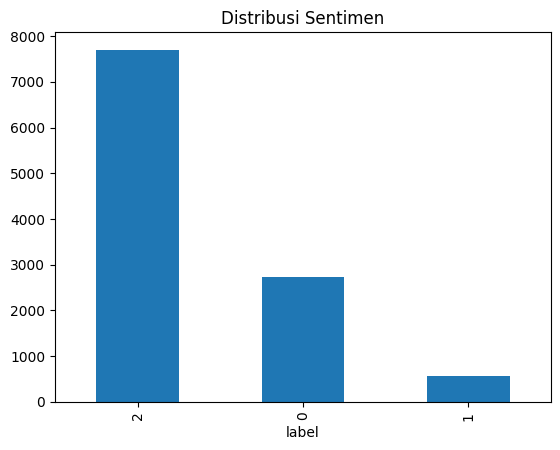

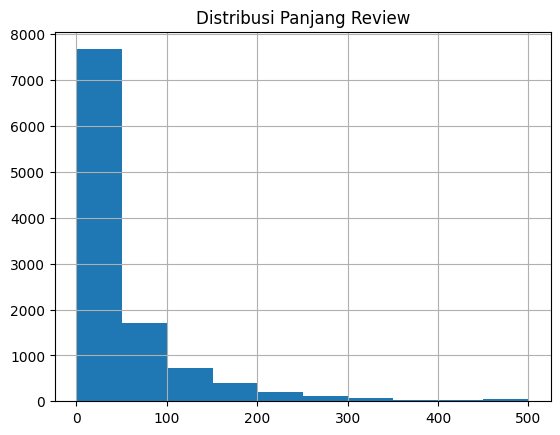

In [7]:


# Load data
df = pd.read_csv("instagram_reviews.csv")
df = df[['content','score']]
df.dropna(inplace=True)

# Rename kolom
df.rename(columns={'content': 'review'}, inplace=True)

# Labeling
def label_sentiment(score):
    if score <= 2:
        return 0
    elif score == 3:
        return 1
    else:
        return 2

df['label'] = df['score'].apply(label_sentiment)

# Distribusi label
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen")
plt.show()

# Panjang teks
df['length'] = df['review'].apply(len)
df['length'].hist()
plt.title("Distribusi Panjang Review")
plt.show()

### Analisis Distribusi Label
Berdasarkan visualisasi, terlihat bahwa distribusi label tidak seimbang (imbalanced), dimana jumlah data pada masing-masing kelas berbeda signifikan. Hal ini dapat menyebabkan model cenderung bias terhadap kelas mayoritas.

### Analisis Panjang Review
Distribusi panjang teks menunjukkan bahwa sebagian besar review memiliki panjang pendek hingga menengah. Hal ini mengindikasikan bahwa pengguna cenderung memberikan ulasan singkat dalam menyampaikan pendapat mereka.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
stop_words = set(stopwords.words('indonesian'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['review'].apply(clean_text)

In [9]:
X = df['clean_text']
y = df['label']

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X.values.reshape(-1,1), y)

df_balanced = pd.DataFrame({
    'clean_text': X_res.flatten(),
    'label': y_res
})

df_balanced['label'].value_counts()

,count
label,
2,7701
0,7701
1,7701


In [10]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df_balanced['clean_text']).toarray()
y = df_balanced['label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(10000,)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7467 - loss: 0.6565 - val_accuracy: 0.8915 - val_loss: 0.3157
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9093 - loss: 0.2763 - val_accuracy: 0.9061 - val_loss: 0.2726
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9266 - loss: 0.2180 - val_accuracy: 0.9099 - val_loss: 0.2677
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9350 - loss: 0.1916 - val_accuracy: 0.9048 - val_loss: 0.2958
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9391 - loss: 0.1761 - val_accuracy: 0.9115 - val_loss: 0.2876
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9427 - loss: 0.1653 - val_accuracy: 0.9113 - val_loss: 0.3018
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9463 - loss: 0.1567 - val_accuracy: 0.9110 - val_loss: 0.2995
Epoch 8/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9462 - loss: 0.1550 - val_accu

In [14]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.914304263146505
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1540
           1       0.97      0.91      0.94      1540
           2       0.87      0.90      0.89      1541

    accuracy                           0.91      4621
   macro avg       0.92      0.91      0.91      4621
weighted avg       0.92      0.91      0.91      4621



In [18]:
# Final dataset
df_balanced = df_balanced[['clean_text', 'label']]

os.makedirs('namadataset_preprocessing', exist_ok=True)

# simpan file
df_balanced.to_csv('namadataset_preprocessing/data_clean.csv', index=False)

print("Preprocessing selesai!")

Preprocessing selesai!
